In [1]:
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Установка библиотек

In [2]:
# @title Импорт
from functools import partial
from IPython.display import HTML
import jax
from jax import random
from jax.nn import relu
import jax.numpy as jnp
import matplotlib
from matplotlib.animation import FuncAnimation
import numpy as np
import optax

seed = 42
np.random.seed(seed)

import tempfile
import matplotlib.pyplot as plt

file_contents = """
# from http://www.huyng.com/posts/sane-color-scheme-for-matplotlib/

patch.linewidth: 0.5
patch.facecolor: 348ABD  # blue
patch.edgecolor: EEEEEE
patch.antialiased: True

font.size: 10.0

axes.linewidth: 1.5
axes.facecolor: white
axes.edgecolor: black
axes.grid: False
axes.titlesize: x-large
axes.labelsize: 18
axes.labelcolor: 555555
axes.axisbelow: True       # grid/ticks are below elements (e.g., lines, text)

xtick.color: 25282A
xtick.major.width: 1.0
xtick.minor.width: 0.75
xtick.direction: out

ytick.color: 25282A
ytick.direction: out
ytick.major.width: 1.0
ytick.minor.width: 0.75

figure.facecolor: white
figure.edgecolor: 0.50
figure.titleweight: bold

text.usetex         : False

legend.frameon      : False
legend.fontsize     : 14.
"""

f = tempfile.NamedTemporaryFile(delete=False, prefix='', suffix='')
mpl_style_name = f.name
f.write(file_contents.encode('utf-8'))
f.close()
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

# Load the style sheet
plt.style.use(mpl_style_name)

custom_colors = [
    '#285780',
    '#E63422',
    '#56C271',
    '#702F8A',
    (139 / 255, 139 / 255, 139 / 255),
]

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [3]:
# @title Basic helpers and scores
def esf(x, y, t):
    t3d = jnp.expand_dims(
        t, 2
    )  # Shape: (batch_size, 1, 1) if t is (batch_size, 1)
    disp_mat = jnp.expand_dims(x, 1) - jnp.expand_dims(
        y, 0
    )  # Shape: (batch_size, n_y, input_dim)
    diff_mat = jnp.sum(
        disp_mat**2, axis=-1, keepdims=True
    )  # Shape: (batch_size, n_y, 1)
    diff_mat = diff_mat - jnp.min(
        diff_mat, axis=1, keepdims=True
    )  # Shape: (batch_size, n_y, 1)
    density_mat = jnp.exp(-diff_mat / (2 * t3d))  # Shape: (batch_size, n_y, 1)
    density_mat = density_mat / jnp.sum(
        density_mat, axis=1, keepdims=True
    )  # Shape: (batch_size, n_y, 1)
    score = jnp.sum(
        disp_mat * density_mat, axis=1
    )  # Shape: (batch_size, input_dim)
    return score / (-t)  # Shape: (batch_size, input_dim)


def rev_ode_solve_sqrt_scheduled(sig_schedule, x_fin, s):
    n = x_fin.shape[0]
    state_dim = x_fin.shape[1]
    n_steps = len(sig_schedule) - 1
    traj = np.zeros((n_steps, n, state_dim))
    x = x_fin
    sig = sig_schedule[-1]
    for i in range(n_steps):
        sig_prev = sig_schedule[-2 - i]
        sig_diff = sig - sig_prev
        t = ((sig + sig_prev) / 2) ** 2
        x = x + s(x, t) * sig_diff * (sig + sig_prev) / 2
        traj[i, :, :] = x
        sig = sig_prev
    return traj


def get_sig_schedule(tmax, n_steps, rho, tmin=0):
    sig_max = np.sqrt(tmax)
    sig_min = np.sqrt(tmin)
    schedule = np.linspace(
        sig_min ** (1 / rho), sig_max ** (1 / rho), n_steps + 1
    )
    sig_schedule = schedule**rho
    return sig_schedule


def sample_pnt(y, n, t, key):
    n_y = y.shape[0]
    state_dim = y.shape[1]
    subkey1, subkey2 = random.split(key)
    rand_indices = random.randint(subkey1, shape=(n,), minval=0, maxval=n_y)
    x_0 = y[rand_indices, :]
    x_t = x_0 + random.normal(subkey2, (n, state_dim)) * jnp.sqrt(t)
    return x_t


def ind_gaussian_pdf(x, mean=0):
    d = x.shape[-1]  # Dimensionality
    normalization = 1.0 / np.power((2 * np.pi), d / 2)
    diff = x - mean
    exponent = -0.5 * np.sum(diff * diff, axis=-1)
    out = normalization * np.exp(exponent)
    return out.astype(np.longdouble)


## The thresholded ESF (for numerical stability when performing sampling-based smoothing)
def esf_truncated(x, y, t, max_score=10):
    t_arr = t * np.ones([x.shape[0], 1])
    score = esf(x, y, t_arr)
    thresh = np.sqrt(max_score / t)
    score = np.minimum(score, thresh)
    score = np.maximum(score, -thresh)
    return score


## Locally-smoothed ESF computed via Monte-Carlo sampling
def esf_mc_smoothed(x, y, t, D=1, n_samples=10, kappa=1, max_score=1):
    batch_size = x.shape[0]
    state_dim = x.shape[1]
    assert state_dim == 2
    n_y = y.shape[0]
    Delta = D / (n_y - 1)
    scale = Delta - np.sqrt(kappa * t)
    if scale < 0:
        print('Bad:', scale, Delta, kappa, t)
    epsilon_x = np.linspace(-scale, scale, int(np.sqrt(n_samples)))
    epsilon_y = np.linspace(-scale, scale, int(np.sqrt(n_samples)))
    xv, yv = np.meshgrid(epsilon_x, epsilon_y)
    epsilon = np.stack([xv, yv], axis=-1).reshape(n_samples, 2)
    x_ptbed = np.expand_dims(x, axis=1) + epsilon
    x_ptbed = np.reshape(x_ptbed, (batch_size * n_samples, state_dim))
    score_ptbed = np.reshape(
        esf_truncated(x_ptbed, y, t, max_score=max_score),
        (batch_size, n_samples, state_dim),
    )
    score_avg = np.mean(score_ptbed, axis=1)
    return score_avg

In [4]:
# @title NN and training
def init_two_layer_nn_res(input_dim, hidden_dim, output_dim, scale=1, key=None):
    W1_init = (
        random.normal(key, (input_dim, hidden_dim))
        * scale
        / np.sqrt(input_dim + hidden_dim)
    )
    W2_init = jnp.zeros((hidden_dim, output_dim))
    Wres_init = jnp.zeros((input_dim, output_dim))
    b1_init = jnp.zeros(
        hidden_dim,
    )
    b2_init = jnp.zeros(
        output_dim,
    )
    return (W1_init, b1_init), (W2_init, b2_init), Wres_init


def init_fun_t_mod(
    input_dim,
    hidden_dim1,
    output_dim,
    t_embed_dim=3,
    t_embed_hidden_dim=32,
    scale=1,
    key=None,
):
    """Initializes parameters for the time-modulated neural network."""
    W1_init = (
        random.normal(key, (input_dim + t_embed_dim, hidden_dim1))
        * scale
        / np.sqrt(input_dim + t_embed_dim + hidden_dim1)
    )
    W2_init = (
        random.normal(key, (input_dim + t_embed_dim + hidden_dim1, output_dim))
        * scale
        / np.sqrt(output_dim + hidden_dim1)
    )
    b1_init = jnp.zeros(
        hidden_dim1,
    )
    b2_init = jnp.zeros(
        output_dim,
    )
    Wt1_init = (
        random.normal(key, (1, t_embed_hidden_dim))
        * scale
        / np.sqrt(1 + t_embed_hidden_dim)
    )
    Wt2_init = (
        random.normal(key, (1 + t_embed_hidden_dim, t_embed_dim))
        * scale
        / np.sqrt(t_embed_dim + t_embed_hidden_dim)
    )
    Wt3_init = jnp.zeros((1 + t_embed_hidden_dim, output_dim))
    bt1_init = jnp.zeros(
        t_embed_hidden_dim,
    )
    bt2_init = jnp.zeros(
        t_embed_dim,
    )
    bt3_init = jnp.zeros(
        output_dim,
    )
    return (
        (W1_init, b1_init),
        (W2_init, b2_init),
        (Wt1_init, bt1_init),
        (Wt2_init, bt2_init),
        (Wt3_init, bt3_init),
    )


def two_layer_nn_res(params, inputs):
    (W1, b1), (W2, b2), Wres = params
    hidden = relu(jnp.dot(inputs, W1) + b1)
    outputs = jnp.dot(hidden, W2) + jnp.dot(inputs, Wres) + b2
    return outputs


def two_layer_nn_res_concat(params, inputs):
    (W1, b1), (W2, b2) = params
    hidden = relu(jnp.dot(inputs, W1) + b1)
    hidden = jnp.concatenate([hidden, inputs], axis=1)
    outputs = jnp.dot(hidden, W2) + b2
    return outputs


def two_layer_nn_t_mod(params, inputs, t):
    (W1, b1), (W2, b2), (Wt1, bt1), (Wt2, bt2), (Wt3, bt3) = params
    t_embed = two_layer_nn_res_concat([(Wt1, bt1), (Wt2, bt2)], t)
    t_mod = two_layer_nn_res_concat([(Wt1, bt1), (Wt3, bt3)], t)
    outputs = two_layer_nn_res_concat(
        [(W1, b1), (W2, b2)], jnp.concatenate([inputs, t_embed], axis=1)
    )
    outputs = outputs * (1 + t_mod)
    return outputs


@partial(
    jax.jit,
    static_argnums=(1, 4,),
)
def squared_loss_fixed_t(params, model, inputs, ytrue, normalize=False):
    preds = model(params, inputs)
    l2err = jnp.mean(jnp.sum(jnp.power(ytrue - preds, 2), axis=1), axis=0)
    if normalize:
        return l2err / jnp.mean(jnp.sum(jnp.power(ytrue, 2), axis=1), axis=0)
    else:
        return l2err


@partial(
    jax.jit,
    static_argnums=(1, 5,),
)
def squared_loss_all_t(params, model, inputs, t, ytrue, normalize=False):
    preds = model(params, inputs, t)
    l2err = jnp.mean(jnp.sum(jnp.power(ytrue - preds, 2), axis=1), axis=0)
    if normalize:
        return l2err / jnp.mean(jnp.sum(jnp.power(ytrue, 2), axis=1), axis=0)
    else:
        return l2err


def nn_fit(
    g,
    batch_size,
    epochs,
    input_dim=1,
    hidden_dim=512,
    lr=0.01,
    seed=seed,
    x_train=None,
    sigma=None,
    wd=0,
):
    """Trains a score model for fixed a fixed time."""
    output_dim = input_dim
    params = init_two_layer_nn_res(
        input_dim, hidden_dim, output_dim, key=random.PRNGKey(seed)
    )

    learning_rate_fn = lr

    wd_mask = (True, True), (True, False), False
    no_wd_mask = (False, False), (False, True), True
    optimizer = optax.chain(
        optax.masked(optax.adamw(learning_rate_fn, weight_decay=wd), wd_mask),
        optax.masked(optax.adam(learning_rate_fn), no_wd_mask),
    )
    opt_state = optimizer.init(params)

    running_loss = 0.0
    for epoch in range(epochs):
        rand_indices = random.randint(
            key=random.PRNGKey(seed + epoch),
            shape=(batch_size,),
            minval=0,
            maxval=x_train.shape[0],
        )
        x_0 = x_train[rand_indices, :]
        noise = (
            random.normal(
                key=random.PRNGKey(seed + epoch), shape=(batch_size, input_dim)
            )
            * sigma
        )
        batch = x_0 + noise
        ytrue = g(batch)
        loss, grads = jax.value_and_grad(squared_loss_fixed_t, argnums=0)(
            params, two_layer_nn_res, batch, ytrue
        )
        updates, opt_state = optimizer.update(grads, opt_state, params)
        running_loss += loss
        if (epoch + 1) % 5000 == 0:
            print(f'Step {epoch+1}: avg_loss={running_loss/5000}')
            running_loss = 0.0
        params = optax.apply_updates(params, updates)

    def f_nn(x):
        return two_layer_nn_res(params, x)

    return f_nn, params


def nn_fit_all_t(
    g,
    batch_size,
    epochs,
    input_dim=1,
    hidden_dim=512,
    lr=0.01,
    seed=seed,
    x_train=None,
    wd=0,
    tmin=0.001,
    tmax=1,
    rho=2,
):
    """Trains a time-dependent score model."""
    output_dim = input_dim
    params = init_fun_t_mod(
        input_dim, hidden_dim, output_dim, key=random.PRNGKey(seed)
    )

    wd_mask = (
        (True, True),
        (True, True),
        (False, False),
        (False, False),
        (False, False),
    )
    no_wd_mask = (
        (False, False),
        (False, False),
        (True, True),
        (True, True),
        (True, True),
    )
    optimizer = optax.chain(
        optax.masked(optax.adamw(lr, weight_decay=wd), wd_mask),
        optax.masked(optax.adam(lr), no_wd_mask),
    )
    opt_state = optimizer.init(params)

    running_loss = 0.0
    for epoch in range(epochs):
        t = (
            np.random.uniform(size=(batch_size, 1))
            * (tmax ** (1 / rho) - tmin ** (1 / rho))
            + tmin ** (1 / rho)
        ) ** rho
        rand_indices = np.random.randint(
            low=0, high=x_train.shape[0], size=(batch_size,)
        )
        x_0 = x_train[rand_indices, :]
        noise = random.normal(
            key=random.PRNGKey(seed + epoch), shape=(batch_size, input_dim)
        ) * jnp.sqrt(t)
        batch = x_0 + noise
        ytrue = g(batch, t)
        loss, grads = jax.value_and_grad(squared_loss_all_t, argnums=0)(
            params, two_layer_nn_t_mod, batch, jnp.log(t), ytrue, False
        )
        updates, opt_state = optimizer.update(grads, opt_state, params)
        running_loss += loss
        if (epoch + 1) % 5000 == 0:
            print(f'Step {epoch+1}: avg_loss={running_loss/5000}')
            running_loss = 0.0
        params = optax.apply_updates(params, updates)

    def f_nn(x, t):
        return two_layer_nn_t_mod(params, x, jnp.log(t))

    return f_nn, params

In [5]:
# @title Distributions and scores with analytical expressions
def pt_n4(tildex, t, Delta):
    a = ind_gaussian_pdf((tildex + 3 * Delta) / np.sqrt(t))
    b = ind_gaussian_pdf((tildex + Delta) / np.sqrt(t))
    c = ind_gaussian_pdf((tildex - Delta) / np.sqrt(t))
    d = ind_gaussian_pdf((tildex - 3 * Delta) / np.sqrt(t))
    return (a + b + c + d)[:, None] / (4 * np.sqrt(t))


def tilde_pt_n4(x, t, kappa, D):
    delta = np.sqrt(t * kappa)
    Delta = D / 3
    type2 = (x[:, 0] < -Delta) & (x[:, 0] >= -3 * Delta)
    type3 = (x[:, 0] < Delta) & (x[:, 0] >= -Delta)
    type4 = (x[:, 0] < 3 * Delta) & (x[:, 0] >= Delta)
    type234 = type2 | type3 | type4
    tildex = np.zeros_like(x)
    tildex[type2, 0] = (
        (Delta - delta) * x[type2, 0] - 2 * delta * Delta
    ) / Delta
    tildex[type3, 0] = ((Delta - delta) * x[type3, 0]) / Delta
    tildex[type4, 0] = (
        (Delta - delta) * x[type4, 0] + 2 * delta * Delta
    ) / Delta
    pt = np.zeros([x.shape[0], 1])
    pt[type234, :] = pt_n4(tildex[type234, :], t, Delta)
    return pt * (Delta - delta) / Delta


def get_tildex_A(x, Delta, delta_t, delta_s, a):
    return ((Delta - delta_t) * x + (delta_t - delta_s) * a) / (Delta - delta_s)


def get_tildex_B(x, delta_t, delta_s, y):
    return (delta_t * x - (delta_t - delta_s) * y) / delta_s


def tilde_pt_s_n4(x, t, s, kappa, D):
    Delta = D / 3
    y_lst = [-3 * Delta, -Delta, Delta, 3 * Delta]
    a_lst = [-2 * Delta, 0, 2 * Delta]
    delta_t = np.sqrt(t * kappa)
    delta_s = np.sqrt(s * kappa)

    typeA1 = (x[:, 0] >= y_lst[0] + delta_s[:, 0]) & (
        x[:, 0] < y_lst[1] - delta_s[:, 0]
    )
    typeA2 = (x[:, 0] >= y_lst[1] + delta_s[:, 0]) & (
        x[:, 0] < y_lst[2] - delta_s[:, 0]
    )
    typeA3 = (x[:, 0] >= y_lst[2] + delta_s[:, 0]) & (
        x[:, 0] < y_lst[3] - delta_s[:, 0]
    )
    typeB1 = x[:, 0] < y_lst[0] + delta_s[:, 0]
    typeB2 = (x[:, 0] >= y_lst[1] - delta_s[:, 0]) & (
        x[:, 0] < y_lst[1] + delta_s[:, 0]
    )
    typeB3 = (x[:, 0] >= y_lst[2] - delta_s[:, 0]) & (
        x[:, 0] < y_lst[2] + delta_s[:, 0]
    )
    typeB4 = x[:, 0] >= y_lst[3] - delta_s[:, 0]
    typeA = typeA1 | typeA2 | typeA3
    typeB = typeB1 | typeB2 | typeB3 | typeB4

    tildex = np.ones_like(x) * 1e-10
    tildex[typeA1, 0] = get_tildex_A(
        x[typeA1, 0], Delta, delta_t[typeA1, 0], delta_s[typeA1, 0], a_lst[0]
    )
    tildex[typeA2, 0] = get_tildex_A(
        x[typeA2, 0], Delta, delta_t[typeA2, 0], delta_s[typeA2, 0], a_lst[1]
    )
    tildex[typeA3, 0] = get_tildex_A(
        x[typeA3, 0], Delta, delta_t[typeA3, 0], delta_s[typeA3, 0], a_lst[2]
    )
    tildex[typeB1, 0] = get_tildex_B(
        x[typeB1, 0], delta_t[typeB1, 0], delta_s[typeB1, 0], y_lst[0]
    )
    tildex[typeB2, 0] = get_tildex_B(
        x[typeB2, 0], delta_t[typeB2, 0], delta_s[typeB2, 0], y_lst[1]
    )
    tildex[typeB3, 0] = get_tildex_B(
        x[typeB3, 0], delta_t[typeB3, 0], delta_s[typeB3, 0], y_lst[2]
    )
    tildex[typeB4, 0] = get_tildex_B(
        x[typeB4, 0], delta_t[typeB4, 0], delta_s[typeB4, 0], y_lst[3]
    )

    pt = np.ones([x.shape[0], 1]) * 1e-12
    pt[typeA, :] += (
        pt_n4(tildex[typeA, :], t[typeA, :], Delta)
        * (Delta - delta_t[typeA, :])
        / (Delta - delta_s[typeA, :])
    )
    pt[typeB, :] += (
        pt_n4(tildex[typeB, :], t[typeB, :], Delta)
        * delta_t[typeB, :]
        / delta_s[typeB, :]
    )
    return pt


def pl_esf(x, y, t):
    score = np.zeros_like(x)
    type1 = x[:, 0] < 0
    type2 = x[:, 0] >= 0
    score[type1, 0] = (y[0, 0] - x[type1, 0]) / t
    score[type2, 0] = (y[1, 0] - x[type2, 0]) / t
    score[:, 1:] = -x[:, 1:] / t
    return score


def smoothed_pl_esf(x, t, kappa=1, D=1):
    Delta = D / (2 - 1)
    a = -1 + np.sqrt(kappa * t)
    b = 1 - np.sqrt(kappa * t)
    score = np.zeros_like(x)
    type1 = x[:, 0] < a
    type2 = x[:, 0] > b
    type3 = (x[:, 0] >= a) & (x[:, 0] <= b)
    score[type1, 0] = (-1 - x[type1, 0]) / t
    score[type2, 0] = (1 - x[type2, 0]) / t
    score[type3, 0] = (
        x[type3, 0] * np.sqrt(kappa * t) / (Delta - np.sqrt(kappa * t)) / t
    )
    score[:, 1:] = -x[:, 1:] / t
    return score


def esf_mc_smoothed(
    x, y, t, D=1, n_samples=10, kappa=1, max_score=1, Delta=None
):
    batch_size = x.shape[0]
    state_dim = x.shape[1]
    n_y = y.shape[0]
    if not Delta:
        Delta = D / (n_y - 1)
    scale = Delta - np.sqrt(kappa * t)
    if scale < 0:
        print('Bad:', scale, Delta, kappa, t)
    if t < 0.0001:
        n_samples_eff = n_samples * 8
    else:
        n_samples_eff = n_samples
    epsilon = (np.random.rand(batch_size, n_samples_eff, state_dim) - 0.5) * (
        scale * 2
    )
    x_ptbed = np.expand_dims(x, axis=1) + epsilon
    x_ptbed = np.reshape(x_ptbed, (batch_size * n_samples_eff, state_dim))
    score_ptbed = np.reshape(
        esf_truncated(x_ptbed, y, t, max_score=max_score),
        (batch_size, n_samples_eff, state_dim),
    )
    score_avg = np.mean(score_ptbed, axis=1)
    return score_avg


def smoothed_pl_esf_n4(x, y, t, kappa=1, D=1):
    Delta = D / 3
    sig = np.sqrt(kappa * t)
    if sig >= Delta:
        print('Bad')
    type2 = x[:, 0] < -3 * Delta + sig
    type3 = (x[:, 0] < -Delta - sig) & (x[:, 0] >= -3 * Delta + sig)
    type4 = (x[:, 0] < -Delta + sig) & (x[:, 0] >= -Delta - sig)
    type5 = (x[:, 0] < Delta - sig) & (x[:, 0] >= -Delta + sig)
    type6 = (x[:, 0] < Delta + sig) & (x[:, 0] >= Delta - sig)
    type7 = (x[:, 0] < 3 * Delta - sig) & (x[:, 0] >= Delta + sig)
    type8 = x[:, 0] >= 3 * Delta - sig
    score = np.zeros_like(x)
    score[type2, 0] = (y[0, 0] - x[type2, 0]) / t
    score[type4, 0] = (y[1, 0] - x[type4, 0]) / t
    score[type6, 0] = (y[2, 0] - x[type6, 0]) / t
    score[type8, 0] = (y[3, 0] - x[type8, 0]) / t
    score[type3, 0] = sig * (x[type3, 0] + 2 * Delta) / ((Delta - sig) * t)
    score[type5, 0] = sig * (x[type5, 0]) / ((Delta - sig) * t)
    score[type7, 0] = sig * (x[type7, 0] - 2 * Delta) / ((Delta - sig) * t)
    score[:, 1:] = -x[:, 1:] / t
    return score

# Заучивание одномерной функции оценки

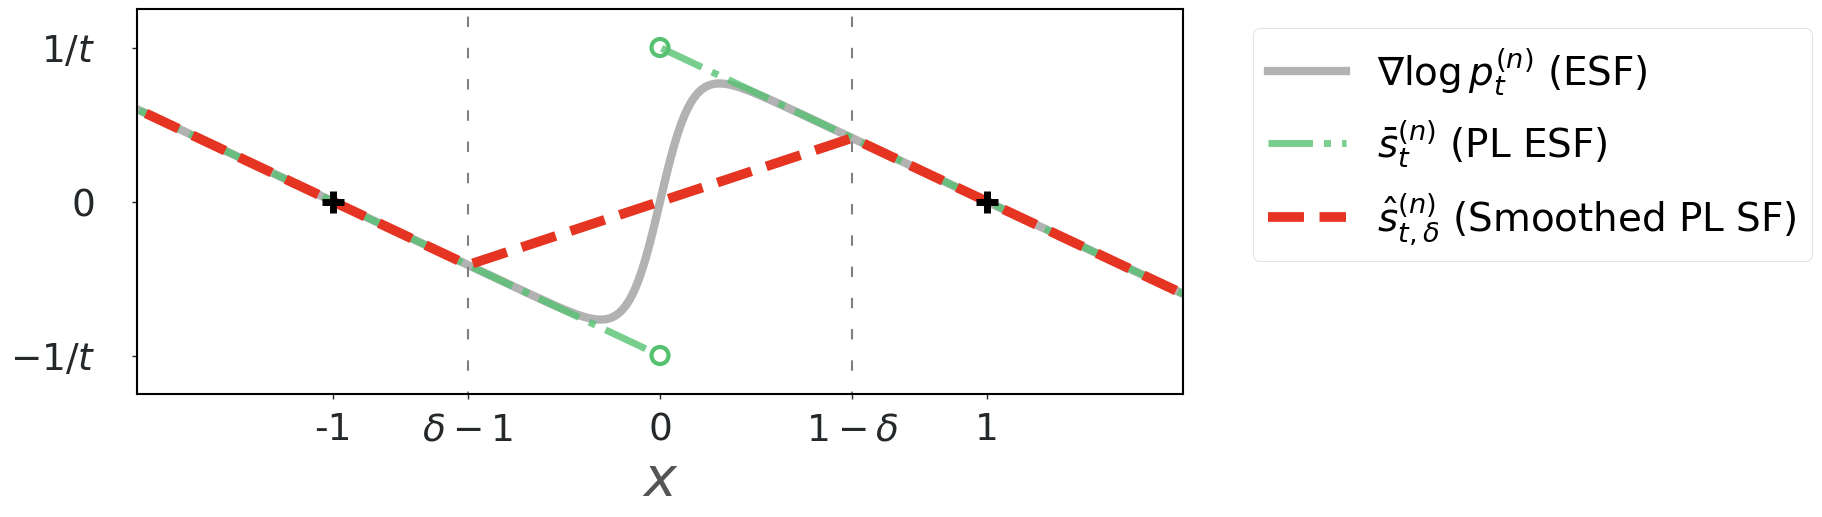

In [6]:
# @title Illustrative plot
n_y = 2
state_dim = 1
y = np.zeros((n_y, state_dim))
D = 1
y[:, 0] = (2 * np.arange(n_y) / (n_y - 1) - 1) * D
t = 0.1
kappa = 1.7
grid_size = 401
x_grid = (np.arange(grid_size + 1) / grid_size - 0.5) * 4
x_grid = np.expand_dims(x_grid, axis=1)
score_funcs = [
    pl_esf(x_grid, y, t),
    smoothed_pl_esf(x_grid, t, D=D, kappa=kappa),
    esf(x_grid, y, t * np.ones((grid_size + 1, 1))),
]
# colors refactored

plt.style.use(mpl_style_name)

fig, ax = plt.subplots(
    1, 1, figsize=(13.5, 5), constrained_layout=False, facecolor='white'
)
fig.patch.set_facecolor('white')

ax.plot(
    x_grid,
    score_funcs[2],
    label=r'$\nabla \log p^{(n)}_{t}$' + ' (ESF)',
    color='k',
    alpha=0.3,
    zorder=0,
    lw=6,
)
ax.scatter(
    [0, 0],
    [-10, 10],
    s=150,
    facecolors='none',
    edgecolors=custom_colors[2],
    linewidth=3,
)
ax.plot(
    x_grid[: grid_size // 2, :],
    score_funcs[0][: grid_size // 2, :],
    '-.',
    label=r'$\bar{s}^{(n)}_t$' + ' (PL ESF)',
    color=custom_colors[2],
    alpha=0.8,
    zorder=1,
    lw=5,
)
ax.plot(
    x_grid[-grid_size // 2 :, :],
    score_funcs[0][-grid_size // 2 :, :],
    '-.',
    color=custom_colors[2],
    alpha=0.8,
    zorder=1,
    lw=5,
)
ax.plot(
    x_grid,
    score_funcs[1],
    '--',
    label=r'$\hat{s}^{(n)}_{t, \delta}$' + ' (Smoothed PL SF)',
    color=custom_colors[1],
    zorder=2,
    alpha=1,
    lw=7,
)
ax.set_ylim([-12.5, 12.5])
ax.set_xlim([-1.6, 1.6])
ax.set_xticks(
    np.array([-1, -1 + np.sqrt(kappa * t), 0, 1 - np.sqrt(kappa * t), 1])
)
ax.set_yticks(np.array([-10, 0, 10]))
ax.set_xticklabels(
    np.array([-1, r'$\delta-1$', 0, r'$1-\delta$', 1]), fontsize=27, y=-0.02
)
ax.set_yticklabels(np.array([r'$-1/t$', 0, r'$1/t$']), fontsize=27, x=-0.03)
ax.legend(
    fontsize=28,
    frameon=True,
    loc='upper right',
    bbox_to_anchor=(1.62, 1),
    facecolor='white',
)
ax.set_xlabel(r'$x$', fontsize=40, y=-0.15)
ax.scatter(
    [-1, 1], [0, 0], marker='+', s=240, lw=5, color='k', alpha=1, zorder=2
)
ax.vlines(
    -1 + np.sqrt(kappa * t), -13, 13, ls=(0, (5, 10)), zorder=0, color='grey'
)
ax.vlines(
    1 - np.sqrt(kappa * t), -13, 13, ls=(0, (5, 10)), zorder=0, color='grey'
)

plt.show()
plt.close()

In [7]:
# @title обучение нейросети (выполняется 1 час 12 минут)
n = 2
x_train = np.arange(n) / (n - 1) * 2 - 1
x_train = np.expand_dims(x_train, axis=1)
t = 0.05
wds = [1, 3, 5, 7]
N = 256
lr = 0.0003

f_dict = {}
params_dict = {}

for i, wd in enumerate(wds):

    def g(x):
        return esf(x, x_train, t * np.ones_like(x)) * np.sqrt(t)

    f, params = nn_fit(
        g,
        input_dim=1,
        batch_size=1024,
        hidden_dim=1024,
        epochs=80001,
        seed=seed,
        wd=wd,
        lr=lr,
        x_train=x_train,
        sigma=np.sqrt(t),
    )
    f_dict[wd] = f
    params_dict[wd] = params

Step 5000: avg_loss=0.2743492126464844
Step 10000: avg_loss=0.08269321918487549
Step 15000: avg_loss=0.03286295384168625
Step 20000: avg_loss=0.015003823675215244
Step 25000: avg_loss=0.008269945159554482
Step 30000: avg_loss=0.0053666154853999615
Step 35000: avg_loss=0.004055986646562815
Step 40000: avg_loss=0.003416621359065175
Step 45000: avg_loss=0.0030377081129699945
Step 50000: avg_loss=0.0026874523609876633
Step 55000: avg_loss=0.0024746034760028124
Step 60000: avg_loss=0.0023598733823746443
Step 65000: avg_loss=0.002250799210742116
Step 70000: avg_loss=0.002229382749646902
Step 75000: avg_loss=0.0021051124203950167
Step 80000: avg_loss=0.0020555502269417048
Step 5000: avg_loss=0.2759018838405609
Step 10000: avg_loss=0.0823078453540802
Step 15000: avg_loss=0.03282513469457626
Step 20000: avg_loss=0.015148435719311237
Step 25000: avg_loss=0.008604240603744984
Step 30000: avg_loss=0.005960435140877962
Step 35000: avg_loss=0.004924264270812273
Step 40000: avg_loss=0.004516499582678

<Figure size 640x480 with 0 Axes>

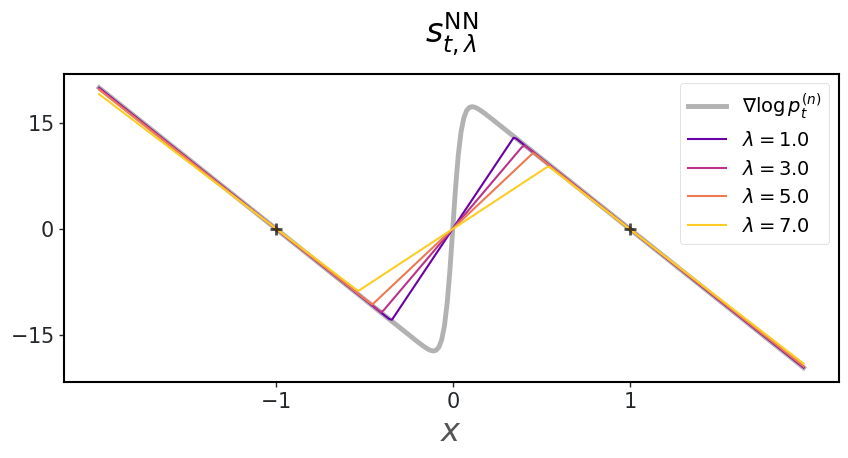

In [8]:
# @title Сравнение нейросети, выучившей функцию оценки и сглаженной функции оценки
cmap = plt.colormaps['plasma']

x_grid = np.arange(N) / (N / 2) - 1
x_grid = np.expand_dims(x_grid * 2, axis=1)
x_2d = np.concatenate([x_grid, np.zeros_like(x_grid)], axis=1)
plt.clf()
fig, ax = plt.subplots(1, 1, figsize=(10, 4), sharey=True)

ax.plot(
    x_grid,
    g(x_2d[:, :1]) / np.sqrt(t),
    color='k',
    alpha=0.3,
    lw=3.5,
    label=r'$\nabla \log p^{(n)}_t$',
)
colors = cmap(np.linspace(0.2, 0.9, len(wds)))
for j, wd in enumerate(wds):
    params = params_dict[wd]

    def f_nn(x):
        return two_layer_nn_res(params, x)

    ax.plot(
        x_grid,
        f_nn(x_grid) / np.sqrt(t),
        label=r'$\lambda=$' + f'{wd:.1f}',
        color=colors[j],
    )
ax.set_xlabel(r'$x$', fontsize=23)
ax.set_xticks([-1, 0, 1])
ax.set_xticklabels([r'$-1$', r'$0$', r'$1$'], fontsize=15)
ax.set_yticks([-15, 0, 15])
ax.set_yticklabels([r'$-15$', r'$0$', r'$15$'], fontsize=15)
ax.set_title(r'$s^{\text{NN}}_{t, \lambda}$', fontsize=24, y=1.1, pad=0)
ax.scatter(
    [-1, 1], [0, 0], marker='+', s=80, lw=2, color='k', alpha=0.7, zorder=2
)
ax.legend(fontsize=14, loc='upper right', bbox_to_anchor=(1, 1), frameon=True)
plt.show()
plt.close()

# Изучение оценки на не униформных обучающих данных

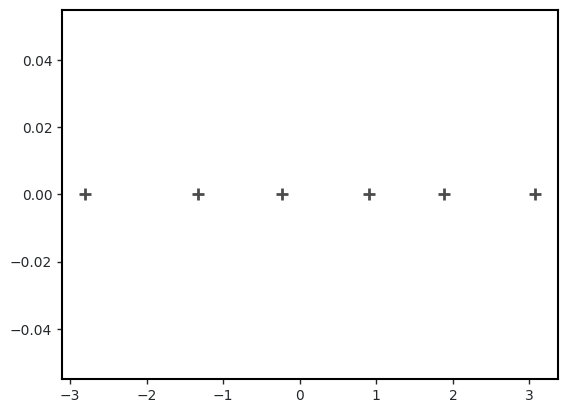

In [9]:
# @title Обучающий набор данных
n = 6
x_train = np.arange(n) / (n - 1) * 2 - 1
x_train = x_train + np.random.rand(n) * 1 / n
x_train = x_train * (n / 2)
x_train = np.expand_dims(x_train, axis=1)

plt.scatter(
    x_train,
    jnp.zeros_like(x_train),
    marker='+',
    s=80,
    lw=2,
    color='k',
    alpha=0.7,
    zorder=2,
)
plt.show()

In [ ]:
# @title Обучение нейросети
t = 0.1
wds = [0, 0.25, 0.5, 1]
N = 256
lr = 0.0002
f_dict_nonuniform = {}
params_dict_nonuniform = {}

for i, wd in enumerate(wds):

    def g(x):
        return esf(x, x_train, t * np.ones([x.shape[0], 1])) * np.sqrt(t)

    f, params = nn_fit(
        g,
        input_dim=1,
        batch_size=1024,
        hidden_dim=1024,
        epochs=60001,
        seed=0,
        wd=wd,
        lr=lr,
        x_train=x_train,
        sigma=np.sqrt(t),
    )
    f_dict_nonuniform[wd] = f
    params_dict_nonuniform[wd] = params

Step 5000: avg_loss=0.4114210903644562
Step 10000: avg_loss=0.39512595534324646
Step 15000: avg_loss=0.38048434257507324
Step 20000: avg_loss=0.3679879903793335
Step 25000: avg_loss=0.35817429423332214
Step 30000: avg_loss=0.34975099563598633
Step 35000: avg_loss=0.34367719292640686
Step 40000: avg_loss=0.33954980969429016
Step 45000: avg_loss=0.3359138071537018
Step 50000: avg_loss=0.3326760232448578
Step 55000: avg_loss=0.331012099981308
Step 60000: avg_loss=0.3294030427932739
Step 5000: avg_loss=0.4123086929321289


In [ ]:
# @title График как нейросеть выучила функцию оценки
kappa_lst = []
wds_plt = wds
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0.2, 0.9, len(wds_plt)))

x_grid = np.arange(N) / (N / 2) - 1
x_grid = np.expand_dims(x_grid * 4, axis=1)
x_2d = np.concatenate([x_grid, np.zeros_like(x_grid)], axis=1)
plt.clf()
fig, axs = plt.subplots(1, 1, figsize=(9, 4), sharey=True)

ax = axs
ax.plot(
    x_grid,
    g(x_2d[:, :1]) / np.sqrt(t),
    color='k',
    alpha=0.3,
    lw=3.5,
    label=r'$\nabla \log p^{(n)}_t$',
)
for j, wd in enumerate(wds_plt):
    f = f_dict_nonuniform[wd]
    ax.plot(
        x_grid,
        f(x_grid) / np.sqrt(t),
        label=r'$\lambda=$' + f'{wd:.2f}',
        color=colors[j],
    )
ax.set_xlabel(r'$x$', fontsize=25)
ax.set_xlim(-3.5, 4)
ax.set_ylim(-9, 9)
ax.set_xticks([-2, 0, 2])
ax.set_xticklabels([r'$-2$', r'$0$', r'$2$'], fontsize=15)
ax.set_yticks([-5, 0, 5])
ax.set_yticklabels([r'$-5$', r'$0$', r'$5$'], fontsize=15)
ax.set_title(r'$s^{\text{NN}}_{t, \lambda}$', fontsize=27, y=1.1, pad=0)
ax.scatter(
    x_train,
    np.zeros_like(x_train),
    marker='+',
    s=130,
    lw=3,
    color='k',
    alpha=0.7,
    zorder=2,
)
ax.legend(
    fontsize=14, loc='upper right', bbox_to_anchor=(1.27, 1.02), frameon=True
)
plt.tight_layout()
plt.show()
plt.close()

# 1-D denoising dynamics

In [ ]:
# @title NN training
ns = [4]
tmax = 0.02
lambs = [0.0]
N = 128
x_grid = np.arange(N) / (N / 2) - 1
x_grid = np.expand_dims(x_grid * 1.5, axis=1)
x_2d = np.concatenate([x_grid, np.zeros_like(x_grid)], axis=1)
lr = 0.00005
n = ns[0]
x_train = np.arange(n) / (n - 1) * 2 - 1
x_train = np.stack([x_train, np.zeros(n)], axis=1)


def g(x, t):
    return esf(x, x_train, t) * t**0.5


f, params = nn_fit_all_t(
    g,
    input_dim=2,
    batch_size=1024,
    hidden_dim=1024,
    epochs=150001,
    seed=0,
    wd=2,
    lr=lr,
    x_train=x_train,
    tmax=tmax,
    tmin=1e-6,
    rho=3,
)

In [ ]:
# @title Inference (denoising dynamics)
n_y = 4
state_dim = 2
D = 1
y = x_train

n = 20000
tmax = 0.02
t = tmax
x_t = sample_pnt(y, n, t, jax.random.PRNGKey(seed))
kappa = 1.44
max_score = 100000
n_samples = 32
n_inference_steps = 50
sig_schedule = get_sig_schedule(tmax, n_inference_steps, rho=2, tmin=1e-5)

traj_esf = rev_ode_solve_sqrt_scheduled(
    sig_schedule, x_t, lambda x, t: esf(x, y, t * np.ones((x.shape[0], 1)))
)
traj_smoothed_pl_esf = rev_ode_solve_sqrt_scheduled(
    sig_schedule, x_t, lambda x, t: smoothed_pl_esf_n4(x, y, t, kappa=kappa, D=D)
)
traj_mc_smoothed_esf = rev_ode_solve_sqrt_scheduled(
    sig_schedule,
    x_t,
    lambda x, t: esf_mc_smoothed(
        x, y, t, D=D, n_samples=n_samples, max_score=max_score, kappa=kappa
    ),
)
traj_nn = rev_ode_solve_sqrt_scheduled(
    sig_schedule,
    x_t,
    lambda x, t: f(x, t * np.ones([x.shape[0], 1])) / (t**0.5),
)

In [ ]:
# @title График сравнения динамики шумоподавления: ESF vs Smoothed PL ESF vs NN-learned SF
n_y = 4
t = tmax

rho = 2
tmid_idx = -int(n_inference_steps / (2 ** (1 / rho)))
tmid = tmax / 4

print('tmid', tmid)
# colors refactored

trajs = [traj_esf, traj_smoothed_pl_esf, traj_nn]

grid_size = 400
n_bins = 73
x_grid = np.arange(grid_size * 2 + 1) / grid_size - 1
x_grid = np.expand_dims(x_grid * 1.4, axis=1)
n_samples_scat = 800

den_0 = tilde_pt_n4(x_grid, t, kappa, D)
den_mid = tilde_pt_s_n4(
    x_grid, t * np.ones_like(x_grid), tmid * np.ones_like(x_grid), kappa, D
)
den_t0 = pt_n4(x_grid, t, D / 3)

dim = 0
if dim == 0:
    bins = ((np.arange(n_bins) - (n_bins / 2 - 1)) / (n_bins - 1) - 0) * 4
elif dim == 1:
    bins = ((np.arange(n_bins) - (n_bins / 2 - 1)) / (n_bins - 2) - 0) * 1

plt.close()
plt.style.use(mpl_style_name)
plt.clf()
fig = plt.figure(figsize=(15, 12))
subfigs = fig.subfigures(3, 1, height_ratios=[0.8, 2, 2], hspace=0.3)


## time t0
subfigsnest = subfigs[0].subfigures(
    1, 5, wspace=0, hspace=0, width_ratios=[0.5, 1, 0.5, 1, 0.5]
)

ax = subfigsnest[1].subplots(1, 1)
ax.scatter(
    trajs[0][0, :n_samples_scat, 0],
    trajs[0][0, :n_samples_scat, 1],
    color=custom_colors[2],
    label=r'$t=t_0$',
    alpha=0.45,
    s=35,
)
ax.scatter(
    [-1, -1 / 3, 1 / 3, 1], [0, 0, 0, 0], marker='+', s=150, lw=3, color='k'
)
ax.set_xlim([-1.4, 1.4])
ax.set_ylim(-0.6, 0.6)
ax.set_xticks(np.array([-1, 0, 1]))
ax.set_xticklabels(np.array([None, None, None]), fontsize=20)
ax.set_yticks(np.array([-0.5, 0, 0.5]))
ax.set_yticklabels(np.array([r'$-0.5$', r'$0$', r'$0.5$']), fontsize=20)
ax.set_xlabel(r'$[\mathbf{x}]_1$', fontsize=25, x=0.52, labelpad=5)
ax.set_ylabel(r'$[\mathbf{x}]_2$', fontsize=25, rotation=0, labelpad=15, y=0.4)

ax = subfigsnest[3].subplots(1, 1)
ax.hist(
    trajs[0][0, :, dim],
    bins=bins,
    density=True,
    label=r'$t=t_0$',
    color=custom_colors[4],
    alpha=0.7,
)
ax.set_yscale('log')
ax.set_xlim([-1.4, 1.4])
ax.set_ylim(0.01, 3)
ax.set_xticks(np.array([-1, 0, 1]))
ax.set_xticklabels(np.array([None, None, None]), fontsize=20)
ax.set_yticks(np.array([0.1, 1]))
ax.set_yticklabels(np.array([r'$0.1$', r'$1$']), fontsize=20)

ax.plot(x_grid, den_t0, color=custom_colors[0], lw=4, alpha=0.75)
ax.set_ylabel(r'$\text{log density}$', fontsize=25)
ax.set_xlabel(r'$[\mathbf{x}]_1$', fontsize=25, x=0.52, labelpad=5)


## time middle
axs = subfigs[1].subplots(2, 3, sharex=True, height_ratios=[1, 1])

for i in range(3):

    ax = axs[0, i]
    ax.scatter(
        trajs[i][tmid_idx, :n_samples_scat, 0],
        trajs[i][tmid_idx, :n_samples_scat, 1],
        color=custom_colors[2],
        label=r'$t=t_0$',
        alpha=0.45,
        s=35,
    )
    ax.scatter(
        [-1, -1 / 3, 1 / 3, 1],
        [0, 0, 0, 0],
        marker='+',
        s=150,
        lw=3,
        color='k',
        zorder=1,
    )
    ax.set_xlim([-1.4, 1.4])
    ax.set_ylim(-0.6, 0.6)
    ax.set_xticks(np.array([-1, 0, 1]))
    ax.set_xticklabels(np.array([r'$-1$', r'$0$', r'$1$']), fontsize=20)
    ax.set_yticks(np.array([-0.5, 0, 0.5]))
    ax.set_yticklabels(np.array([None, None, None]), fontsize=20)

    if i == 0:
        ax.set_ylabel(
            r'$[\mathbf{x}]_2$', fontsize=25, rotation=0, labelpad=23, y=0.4
        )
        ax.set_yticklabels(np.array([-0.5, 0, 0.5]), fontsize=20)

    ax = axs[1, i]
    ax.hist(
        trajs[i][tmid_idx, :, dim],
        bins=bins,
        density=True,
        label=r'$t=t_0$',
        color=custom_colors[4],
        alpha=0.7,
    )
    ax.set_yscale('log')

    if dim == 0:
        ax.set_xlim([-1.4, 1.4])
        ax.set_ylim(0.01, 3)
        ax.set_xticks(np.array([-1, 0, 1]))
        ax.set_xticklabels(np.array([None, None, None]), fontsize=20)
        ax.set_yticks(np.array([0.1, 1]))
        ax.set_yticklabels(np.array([None, None]), fontsize=20)

    if i >= 0:
        ax.plot(x_grid, den_mid, color=custom_colors[3], lw=4, alpha=0.75)

    if i == 0:
        ax.set_yticklabels(np.array([r'$0.1$', r'$1$']), fontsize=20)
        ax.set_ylabel(r'$\text{log density}$', fontsize=25)

## time 0
axs = subfigs[2].subplots(2, 3, sharex=True, height_ratios=[1, 1])

for i in range(3):

    ax = axs[0, i]
    ax.scatter(
        trajs[i][-1, :n_samples_scat, 0],
        trajs[i][-1, :n_samples_scat, 1],
        color=custom_colors[2],
        label=r'$t=0$',
        alpha=0.45,
        s=42 if i == 0 else 35,
    )
    ax.scatter(
        [-1, -1 / 3, 1 / 3, 1],
        [0, 0, 0, 0],
        marker='+',
        s=150,
        lw=3,
        color='k',
        zorder=1,
        alpha=0.5 if i == 0 else 1,
    )
    ax.set_xlim([-1.4, 1.4])
    ax.set_ylim(-0.42, 0.42)
    ax.set_xticks(np.array([-1, 0, 1]))
    ax.set_xticklabels(np.array([r'$-1$', r'$0$', r'$1$']), fontsize=20)
    ax.set_yticks(np.array([-0.3, 0, 0.3]))
    ax.set_yticklabels(np.array([None, None, None]), fontsize=20)

    if i == 0:
        ax.set_yticklabels(np.array([-0.3, 0, 0.3]), fontsize=20)
        ax.set_ylabel(
            r'$[\mathbf{x}]_2$', fontsize=25, rotation=0, labelpad=23, y=0.4
        )

    ax = axs[1, i]
    ax.hist(
        trajs[i][-1, :, dim],
        bins=bins,
        density=True,
        label=r'$t=0$',
        color=custom_colors[4],
        alpha=0.7,
    )
    ax.set_yscale('log')
    ax.set_xlabel(r'$[\mathbf{x}]_1$', fontsize=25, x=0.52, labelpad=5)

    if dim == 0:
        ax.set_xlim([-1.4, 1.4])
        ax.set_ylim(0.01, 3)
        ax.set_xticks(np.array([-1, 0, 1]))
        ax.set_xticklabels(np.array([None, None, None]), fontsize=20)
        ax.set_yticks(np.array([0.1, 1]))
        ax.set_yticklabels(np.array([None, None]), fontsize=20)

    if i >= 0:
        ax.plot(x_grid, den_0, color=custom_colors[1], lw=4, alpha=0.75)

    if i == 0:
        ax.set_yticklabels(np.array([r'$0.1$', r'$1$']), fontsize=20)
        ax.set_ylabel(r'$\text{log density}$', fontsize=25)


fig.text(1.02, 0.92, r'$t=t_0$', ha='left', fontsize=25)
fig.text(1.02, 0.59, r'$t=t_0/4$', ha='left', fontsize=25)
fig.text(1.02, 0.16, r'$t \approx 0$', ha='left', fontsize=25)
plt.tight_layout()

r = fig.canvas.get_renderer()
axes = axs
get_bbox = lambda ax: ax.get_tightbbox(r).transformed(
    fig.transFigure.inverted()
)
ys = [0.38, 0.805]

for y in ys:
    line = plt.Line2D(
        [-0.07, 1.1],
        [y, y],
        transform=fig.transFigure,
        color='black',
        ls='dashed',
    )
    fig.add_artist(line)

plt.show()
plt.close()

In [ ]:
# @title График сравнения динамики шумоподавления: ESF vs Smoothed PL ESF vs Numerically-smoothed ESF
t = tmax
rho = 2
tmid_idx = -int(n_inference_steps / (2 ** (1 / rho)))
tmid = tmax / 4

trajs = [traj_esf, traj_smoothed_pl_esf, traj_mc_smoothed_esf]

grid_size = 400
n_bins = 73
x_grid = np.arange(grid_size * 2 + 1) / grid_size - 1
x_grid = np.expand_dims(x_grid * 1.4, axis=1)
n_samples_scat = 800

den_0 = tilde_pt_n4(x_grid, t, kappa, D)
den_mid = tilde_pt_s_n4(
    x_grid, t * np.ones_like(x_grid), tmid * np.ones_like(x_grid), kappa, D
)
den_t0 = pt_n4(x_grid, t, D / 3)

dim = 0
if dim == 0:
    bins = ((np.arange(n_bins) - (n_bins / 2 - 1)) / (n_bins - 1) - 0) * 4
elif dim == 1:
    bins = ((np.arange(n_bins) - (n_bins / 2 - 1)) / (n_bins - 2) - 0) * 1

plt.close()
plt.style.use(mpl_style_name)
plt.clf()
fig = plt.figure(figsize=(15, 12))
subfigs = fig.subfigures(3, 1, height_ratios=[0.8, 2, 2], hspace=0.3)


## time t0
subfigsnest = subfigs[0].subfigures(
    1, 5, wspace=0, hspace=0, width_ratios=[0.5, 1, 0.5, 1, 0.5]
)

ax = subfigsnest[1].subplots(1, 1)
ax.scatter(
    trajs[0][0, :n_samples_scat, 0],
    trajs[0][0, :n_samples_scat, 1],
    color=custom_colors[2],
    label=r'$t=t_0$',
    alpha=0.45,
    s=35,
)
ax.scatter(
    [-1, -1 / 3, 1 / 3, 1], [0, 0, 0, 0], marker='+', s=150, lw=3, color='k'
)
ax.set_xlim([-1.4, 1.4])
ax.set_ylim(-0.6, 0.6)
ax.set_xticks(np.array([-1, 0, 1]))
ax.set_xticklabels(np.array([None, None, None]), fontsize=20)
ax.set_yticks(np.array([-0.5, 0, 0.5]))
ax.set_yticklabels(np.array([r'$-0.5$', r'$0$', r'$0.5$']), fontsize=20)
ax.set_xlabel(r'$[\mathbf{x}]_1$', fontsize=25, x=0.52, labelpad=5)
ax.set_ylabel(r'$[\mathbf{x}]_2$', fontsize=25, rotation=0, labelpad=15, y=0.4)

ax = subfigsnest[3].subplots(1, 1)
ax.hist(
    trajs[0][0, :, dim],
    bins=bins,
    density=True,
    label=r'$t=t_0$',
    color=custom_colors[4],
    alpha=0.7,
)
ax.set_yscale('log')
ax.set_xlim([-1.4, 1.4])
ax.set_ylim(0.01, 3)
ax.set_xticks(np.array([-1, 0, 1]))
ax.set_xticklabels(np.array([None, None, None]), fontsize=20)
ax.set_yticks(np.array([0.1, 1]))
ax.set_yticklabels(np.array([r'$0.1$', r'$1$']), fontsize=20)

ax.plot(x_grid, den_t0, color=custom_colors[0], lw=4, alpha=0.75)
ax.set_ylabel(r'$\text{log density}$', fontsize=25)
ax.set_xlabel(r'$[\mathbf{x}]_1$', fontsize=25, x=0.52, labelpad=5)


## time middle
axs = subfigs[1].subplots(2, 3, sharex=True, height_ratios=[1, 1])

for i in range(3):

    ax = axs[0, i]
    ax.scatter(
        trajs[i][tmid_idx, :n_samples_scat, 0],
        trajs[i][tmid_idx, :n_samples_scat, 1],
        color=custom_colors[2],
        label=r'$t=t_0$',
        alpha=0.45,
        s=35,
    )
    ax.scatter(
        [-1, -1 / 3, 1 / 3, 1],
        [0, 0, 0, 0],
        marker='+',
        s=150,
        lw=3,
        color='k',
        zorder=1,
    )
    ax.set_xlim([-1.4, 1.4])
    ax.set_ylim(-0.6, 0.6)
    ax.set_xticks(np.array([-1, 0, 1]))
    ax.set_xticklabels(np.array([r'$-1$', r'$0$', r'$1$']), fontsize=20)
    ax.set_yticks(np.array([-0.5, 0, 0.5]))
    ax.set_yticklabels(np.array([None, None, None]), fontsize=20)

    if i == 0:
        ax.set_ylabel(
            r'$[\mathbf{x}]_2$', fontsize=25, rotation=0, labelpad=23, y=0.4
        )
        ax.set_yticklabels(np.array([-0.5, 0, 0.5]), fontsize=20)

    ax = axs[1, i]
    ax.hist(
        trajs[i][tmid_idx, :, dim],
        bins=bins,
        density=True,
        label=r'$t=t_0$',
        color=custom_colors[4],
        alpha=0.7,
    )
    ax.set_yscale('log')

    if dim == 0:
        ax.set_xlim([-1.4, 1.4])
        ax.set_ylim(0.01, 3)
        ax.set_xticks(np.array([-1, 0, 1]))
        ax.set_xticklabels(np.array([None, None, None]), fontsize=20)
        ax.set_yticks(np.array([0.1, 1]))
        ax.set_yticklabels(np.array([None, None]), fontsize=20)

    if i >= 0:
        ax.plot(x_grid, den_mid, color=custom_colors[3], lw=4, alpha=0.75)

    if i == 0:
        ax.set_yticklabels(np.array([r'$0.1$', r'$1$']), fontsize=20)
        ax.set_ylabel(r'$\text{log density}$', fontsize=25)

## time 0
axs = subfigs[2].subplots(2, 3, sharex=True, height_ratios=[1, 1])

for i in range(3):

    ax = axs[0, i]
    ax.scatter(
        trajs[i][-1, :n_samples_scat, 0],
        trajs[i][-1, :n_samples_scat, 1],
        color=custom_colors[2],
        label=r'$t=0$',
        alpha=0.45,
        s=42 if i == 0 else 35,
    )
    ax.scatter(
        [-1, -1 / 3, 1 / 3, 1],
        [0, 0, 0, 0],
        marker='+',
        s=150,
        lw=3,
        color='k',
        zorder=1,
        alpha=0.5 if i == 0 else 1,
    )
    ax.set_xlim([-1.4, 1.4])
    ax.set_ylim(-0.42, 0.42)
    ax.set_xticks(np.array([-1, 0, 1]))
    ax.set_xticklabels(np.array([r'$-1$', r'$0$', r'$1$']), fontsize=20)
    ax.set_yticks(np.array([-0.3, 0, 0.3]))
    ax.set_yticklabels(np.array([None, None, None]), fontsize=20)

    if i == 0:
        ax.set_yticklabels(np.array([-0.3, 0, 0.3]), fontsize=20)
        ax.set_ylabel(
            r'$[\mathbf{x}]_2$', fontsize=25, rotation=0, labelpad=23, y=0.4
        )

    ax = axs[1, i]
    ax.hist(
        trajs[i][-1, :, dim],
        bins=bins,
        density=True,
        label=r'$t=0$',
        color=custom_colors[4],
        alpha=0.7,
    )
    ax.set_yscale('log')
    ax.set_xlabel(r'$[\mathbf{x}]_1$', fontsize=25, x=0.52, labelpad=5)

    if dim == 0:
        ax.set_xlim([-1.4, 1.4])
        ax.set_ylim(0.01, 3)
        ax.set_xticks(np.array([-1, 0, 1]))
        ax.set_xticklabels(np.array([None, None, None]), fontsize=20)
        ax.set_yticks(np.array([0.1, 1]))
        ax.set_yticklabels(np.array([None, None]), fontsize=20)

    if i >= 0:
        ax.plot(x_grid, den_0, color=custom_colors[1], lw=4, alpha=0.75)

    if i == 0:
        ax.set_yticklabels(np.array([r'$0.1$', r'$1$']), fontsize=20)
        ax.set_ylabel(r'$\text{log density}$', fontsize=25)


fig.text(1.02, 0.92, r'$t=t_0$', ha='left', fontsize=25)
fig.text(1.02, 0.59, r'$t=t_0/4$', ha='left', fontsize=25)
fig.text(1.02, 0.16, r'$t \approx 0$', ha='left', fontsize=25)
plt.tight_layout()

ys = [0.38, 0.805]

for y in ys:
    line = plt.Line2D(
        [-0.07, 1.1],
        [y, y],
        transform=fig.transFigure,
        color='black',
        ls='dashed',
    )
    fig.add_artist(line)

plt.show()
plt.close()

In [ ]:
# @title Анимация

n_bins = 73
bins = ((np.arange(n_bins) - (n_bins / 2 - 1)) / (n_bins - 1) - 0) * 4
grid_size = 2000
x_grid = np.arange(grid_size * 2 + 1) / grid_size - 1
x_grid = np.expand_dims(x_grid * 1.6, axis=1)

plt.clf()
fig, axes = plt.subplots(
    4,
    3,
    figsize=(15, 12.5),
    sharex=False,
    sharey=False,
    height_ratios=(1, 1.3, 1.3, 1.3),
)
trajs = [traj_esf, traj_smoothed_pl_esf, traj_nn]
titles = [
    r'$\mathbf{s}_t=\nabla \log p^{(n)}_t$',
    r'$\mathbf{s}_t=\hat{\mathbf{s}}^{(n)}_{t, \delta_t}$',
    r'$\mathbf{s}_t=\mathbf{s}^{\text{NN}}_{t}$',
]
scores = [
    lambda x, t: esf(x, x_train, t * np.ones((x.shape[0], 1))),
    lambda x, t: smoothed_pl_esf_n4(x, x_train, t, kappa=kappa, D=D),
    lambda x, t: two_layer_nn_t_mod(
        params, x, np.log(t) * np.ones([x.shape[0], 1])
    )
    / (t**0.5),
]

scats = []
score1s = []
score2s = []
bars_all = []

(curve,) = axes[1, 1].plot([], [], color=custom_colors[1], lw=3, alpha=0.75)
(curve2,) = axes[1, 2].plot([], [], color=custom_colors[1], lw=3, alpha=0.75)
(curve0,) = axes[1, 0].plot([], [], color=custom_colors[1], lw=3, alpha=0.75)
for i in range(3):
    ax = axes[0, i]
    (scat,) = ax.plot([], [], 'o', markersize=3.5, color=custom_colors[2])
    scats.append(scat)
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-0.6, 0.6)
    ax.hlines(0, -3, 3, 'k', '--', lw=0.5)
    ax.vlines(0, -3, 3, 'k', '--', lw=0.5)
    ax.set_title(titles[i], fontsize=22, y=1.15)
    ax.set_yticks(np.array([-0.5, 0, 0.5]))
    if i == 0:
        ax.set_yticklabels(np.array([r'$-0.5$', r'$0$', r'$0.5$']), fontsize=15)
        ax.set_ylabel(
            r'$[\mathbf{x}]_2$',
            rotation=0,
            fontsize=20,
            va='center',
            ha='right',
        )
    else:
        ax.set_yticklabels(np.array([None, None, None]), fontsize=15)

    if i == 1:
        text_obj = ax.text(
            0.0, 1.5, 't=0.02000', ha='center', va='center', fontsize=22
        )

    ax = axes[1, i]
    hist, _ = np.histogram(trajs[i][0, :, 0], bins=bins, density=True)
    bars = ax.bar(
        bins[:-1], hist, width=np.diff(bins), align='edge', color='k', alpha=0.4
    )
    bars_all.append(bars)
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(0.01, 5)
    ax.set_yscale('log')
    ax.set_yticks(np.array([0.1, 1]))
    if i == 0:
        ax.set_yticklabels(np.array([r'$0.1$', r'$1$']), fontsize=15)
        ax.set_ylabel(
            r'$\text{log density}$',
            fontsize=20,
            rotation=0,
            labelpad=10,
            va='center',
            ha='right',
        )
    else:
        ax.set_yticklabels(np.array([None, None]), fontsize=15)

    ax = axes[2, i]
    (score1,) = ax.plot([], [], color=custom_colors[0], lw=4, alpha=1)
    score1s.append(score1)
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-7, 7)
    ax.set_yticks(np.array([-10, 0, 10]))
    if i == 0:
        ax.set_yticklabels(np.array([r'$-10$', r'$0$', r'$10$']), fontsize=15)
        ax.set_ylabel(
            r'$\sqrt{t} \cdot [\mathbf{s}_t([x, 0]^{\mathtt{T}})]_1$'
            + '\n\n'
            + '(tangent)',
            rotation=0,
            fontsize=20,
            va='center',
            ha='center',
            labelpad=75,
        )
    else:
        ax.set_yticklabels(np.array([None, None, None]), fontsize=15)

    ax = axes[3, i]
    (score2,) = ax.plot([], [], color=custom_colors[0], lw=4, alpha=1)
    score2s.append(score2)
    ax.set_xlim(-0.16, 0.16)
    ax.set_ylim(-7, 7)
    ax.set_yticks(np.array([-10, 0, 10]))
    if i == 0:
        ax.set_yticklabels(np.array([r'$-10$', r'$0$', r'$10$']), fontsize=15)
        ax.set_ylabel(
            r'$\sqrt{t} \cdot [\mathbf{s}_t([0, x]^{\mathtt{T}})]_2$'
            + '\n\n'
            + '(normal)',
            rotation=0,
            fontsize=20,
            va='center',
            ha='center',
            labelpad=75,
        )
    else:
        ax.set_yticklabels(np.array([None, None, None]), fontsize=15)

for j in range(3):
    for i in range(3):
        axes[i, j].set_xticks(np.array([-1, 0, 1]))
        axes[i, j].set_xticklabels(
            np.array([r'$-1$', r'$0$', r'$1$']), fontsize=15
        )
        if i == 0 or i == 1:
            axes[i, j].set_xlabel(r'$[\mathbf{x}]_1$', fontsize=20)
        else:
            axes[i, j].set_xlabel(r'$x$', fontsize=20)
    axes[-1, j].set_xticks(np.array([-0.1, 0, 0.1]))
    axes[-1, j].set_xticklabels(
        np.array([r'$-0.1$', r'$0$', r'$0.1$']), fontsize=15
    )
    axes[-1, j].set_xlabel(r'$x$', fontsize=20)
    axes[0, j].scatter(
        [-D, -D / 3, D / 3, D],
        [0, 0, 0, 0],
        marker='+',
        s=80,
        lw=2,
        color='k',
        alpha=0.7,
        zorder=2,
    )


def animate(k):
    s = sig_schedule[-k - 1] ** 2
    den = tilde_pt_s_n4(
        x_grid, tmax * np.ones_like(x_grid), s * np.ones_like(x_grid), kappa, D
    )
    curve.set_data(x_grid, den)
    curve2.set_data(x_grid, den)
    curve0.set_data(x_grid, den)
    text_obj.set_text(f't={s:.5f}')
    for i in range(0, 3):
        scats[i].set_data(trajs[i][k, :1000, 0], trajs[i][k, :1000, 1])
        hist, _ = np.histogram(trajs[i][k, :, 0], bins=bins, density=True)
        for bar, y in zip(bars_all[i], hist):
            bar.set_height(y)
        score1s[i].set_data(
            x_grid,
            np.sqrt(s)
            * scores[i](
                np.concatenate([x_grid, np.zeros_like(x_grid)], axis=-1), s
            )[:, :1],
        )
        score2s[i].set_data(
            x_grid,
            np.sqrt(s)
            * scores[i](
                np.concatenate([np.zeros_like(x_grid), x_grid], axis=-1), s
            )[:, 1:],
        )
    return (
        *scats,
        *score1s,
        *score2s,
        curve,
        curve2,
        text_obj,
        *list(bars_all[0]),
        *list(bars_all[1]),
        *list(bars_all[2]),
    )


plt.tight_layout()

ani = FuncAnimation(
    fig,
    animate,
    frames=n_inference_steps,
    interval=10,
    blit=False,
    cache_frame_data=False,
)
HTML(ani.to_jshtml())

In [ ]:
# @title График: функция оценки в двумерных координатах (вывод по оси 1)
ts = [tmax / 2, tmax / 4, tmax / 8]

kappa = 1.44

scores = [
    lambda x, t: esf(x, x_train, t * np.ones((x.shape[0], 1))),
    lambda x, t: smoothed_pl_esf_n4(x, x_train, t, kappa=kappa, D=D),
    lambda x, t: two_layer_nn_t_mod(
        params, x, np.log(t) * np.ones([x.shape[0], 1])
    )
    / (t**0.5),
]
titles = [
    r'$[\nabla \log p^{(n)}_t(\mathbf{x})]_1$',
    r'$[\hat{\mathbf{s}}^{(n)}_{t, \delta_t}(\mathbf{x})]_1$',
    r'$[\mathbf{s}^{\text{NN}}_{t}(\mathbf{x})]_1$',
]

grid_size_x = 200
grid_size_y = 100
x_values = np.linspace(-1.3, 1.3, grid_size_x)
y_values = np.linspace(-0.3, 0.3, grid_size_y)
X, Y = np.meshgrid(x_values, y_values, indexing='ij')
x_2d = np.stack([X, Y], axis=2)
x_2d = x_2d.reshape(grid_size_x * grid_size_y, 2)

plt.clf()
fig, axes = plt.subplots(
    len(ts),
    len(scores),
    subplot_kw={'projection': '3d'},
    figsize=(20, 7 * len(ts)),
)

for i, t in enumerate(ts):
    for j, score in enumerate(scores):
        ax = axes[i][j]
        tmp_planes = ax.zaxis._PLANES
        ax.zaxis._PLANES = (
            tmp_planes[2],
            tmp_planes[3],
            tmp_planes[0],
            tmp_planes[1],
            tmp_planes[4],
            tmp_planes[5],
        )
        view_2 = (15, -75)
        init_view = view_2
        ax.view_init(*init_view)

        E = score(x_2d, t)
        E = E.reshape(grid_size_x, grid_size_y, 2)
        ax.plot_surface(
            X,
            Y,
            E[:, :, 0],
            cmap='coolwarm',
            vmin=-100,
            vmax=100,
            linewidth=0,
            antialiased=False,
        )
        ax.set_yticks(np.array([-0.2, 0, 0.2]))
        ax.set_xticks(np.array([-1, 0, 1]))
        ax.grid(False)
        ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
        ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
        ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-0.3, 0.3)
        ax.set_zlim(-150, 150)

        if i == len(ts) - 1:
            ax.set_xticklabels(np.array([r'$-1$', r'$0$', r'$1$']), fontsize=20)
            ax.set_xlabel(r'$[\mathbf{x}]_1$', fontsize=24, labelpad=20)
        else:
            ax.set_xticklabels([])
        if j == len(scores) - 1:
            ax.set_yticklabels(
                np.array([r'$-0.2$', r'$0$', r'$0.2$']), fontsize=20
            )
            ax.set_ylabel(r'$[\mathbf{x}]_2$', fontsize=24, labelpad=20)
        else:
            ax.set_yticklabels([])

        if i == 0:
            ax.set_title(titles[j], fontsize=29, y=0.95)

        ax.set_zticks(np.array([-100, 0, 100]))
        if j == 0:
            ax.set_zticklabels(
                np.array([r'$-100$', r'$0$', r'$100$']),
                fontsize=20,
                horizontalalignment='right',
            )
        else:
            ax.set_zticklabels([], fontsize=16, horizontalalignment='right')


fig.text(0.9, 0.72, r'$t=t_0/2$', ha='left', fontsize=23)
fig.text(0.9, 0.48, r'$t=t_0/4$', ha='left', fontsize=23)
fig.text(0.9, 0.24, r'$t=t_0/8$', ha='left', fontsize=23)

plt.tight_layout(pad=10)
plt.subplots_adjust(
    left=0, bottom=None, right=None, top=None, wspace=-0.2, hspace=-0.1
)
plt.show()
plt.close()

In [ ]:
# @title График: функция оценки в двумерных координатах (вывод по оси 2)
ts = [tmax / 2, tmax / 4, tmax / 8]
kappa = 1.44

scores = [
    lambda x, t: esf(x, x_train, t * np.ones((x.shape[0], 1))),
    lambda x, t: smoothed_pl_esf_n4(x, x_train, t, kappa=kappa, D=D),
    lambda x, t: two_layer_nn_t_mod(
        params, x, np.log(t) * np.ones([x.shape[0], 1])
    )
    / (t**0.5),
]
titles = [
    r'$[\nabla \log p^{(n)}_t(\mathbf{x})]_2$',
    r'$[\hat{\mathbf{s}}^{(n)}_{t, \delta_t}(\mathbf{x})]_2$',
    r'$[\mathbf{s}^{\text{NN}}_{t}(\mathbf{x})]_2$',
]

grid_size_x = 200
grid_size_y = 100
x_values = np.linspace(-1.3, 1.3, grid_size_x)
y_values = np.linspace(-0.3, 0.3, grid_size_y)
X, Y = np.meshgrid(x_values, y_values, indexing='ij')
x_2d = np.stack([X, Y], axis=2)
x_2d = x_2d.reshape(grid_size_x * grid_size_y, 2)

plt.close()
plt.style.use(mpl_style_name)
plt.clf()
fig, axes = plt.subplots(
    len(ts),
    len(scores),
    subplot_kw={'projection': '3d'},
    figsize=(20, 7 * len(ts)),
)

for i, t in enumerate(ts):
    for j, score in enumerate(scores):
        ax = axes[i][j]
        tmp_planes = ax.zaxis._PLANES
        ax.zaxis._PLANES = (
            tmp_planes[2],
            tmp_planes[3],
            tmp_planes[0],
            tmp_planes[1],
            tmp_planes[4],
            tmp_planes[5],
        )
        view_2 = (10, 140)
        init_view = view_2
        ax.view_init(*init_view)

        E = score(x_2d, t)
        E = E.reshape(grid_size_x, grid_size_y, 2)
        ax.plot_surface(
            X,
            Y,
            E[:, :, 1],
            cmap='coolwarm',
            vmin=-100,
            vmax=100,
            linewidth=0,
            antialiased=False,
        )
        ax.set_yticks(np.array([-0.2, 0, 0.2]))
        ax.set_xticks(np.array([-1, 0, 1]))
        ax.grid(False)
        ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
        ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
        ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-0.3, 0.3)
        ax.set_zlim(-150, 150)

        if i == len(ts) - 1:
            ax.set_xticklabels(np.array([r'$-1$', r'$0$', r'$1$']), fontsize=20)
            ax.set_xlabel(r'$[\mathbf{x}]_1$', fontsize=24, labelpad=20)
        else:
            ax.set_xticklabels([])
        if j == len(scores) - 1:
            ax.set_yticklabels(
                np.array([r'$-0.2$', r'$0$', r'$0.2$']), fontsize=20
            )
            ax.set_ylabel(r'$[\mathbf{x}]_2$', fontsize=24, labelpad=20)
        else:
            ax.set_yticklabels([])

        if i == 0:
            ax.set_title(titles[j], fontsize=29, y=0.95)

        ax.set_zticks(np.array([-100, 0, 100]))
        if j == 0:
            ax.set_zticklabels(
                np.array([r'$-100$', r'$0$', r'$100$']),
                fontsize=20,
                horizontalalignment='right',
            )
        else:
            ax.set_zticklabels([])

fig.text(0.9, 0.72, r'$t=t_0/2$', ha='left', fontsize=23)
fig.text(0.9, 0.48, r'$t=t_0/4$', ha='left', fontsize=23)
fig.text(0.9, 0.24, r'$t=t_0/8$', ha='left', fontsize=23)

plt.tight_layout(pad=10)
plt.subplots_adjust(
    left=0, bottom=None, right=None, top=None, wspace=-0.3, hspace=0
)
plt.show()
plt.close()

In [ ]:
# @title График: выборока из функци и оценки (вход по оси = выход по оси  = 1)
ts = [tmax / 2, tmax / 4, tmax / 8]
ts_str = [r'$t=t_0 / 2$', r'$t=t_0/4$', r'$t=t_0/8$']
kappa = 1.44

scores = [
    lambda x, t: esf(x, x_train, t * np.ones((x.shape[0], 1))),
    lambda x, t: smoothed_pl_esf_n4(x, x_train, t, kappa=kappa, D=D),
    lambda x, t: two_layer_nn_t_mod(
        params, x, np.log(t) * np.ones([x.shape[0], 1])
    )
    / (t**0.5),
]

titles = [
    r'$\mathbf{s}_t = \nabla \log p^{(n)}_t$',
    r'$\mathbf{s}_t = \hat{\mathbf{s}}^{(n)}_{t, \delta_t}$',
    r'$\mathbf{s}_t = \mathbf{s}^{\text{NN}}_{t}$',
]
lss = [':', '-', '--', '-']
N = 256
x_grid = np.arange(N) / (N / 2) - 1
x_grid = np.expand_dims(x_grid * 1.4, axis=1)
x_2d = np.concatenate([x_grid, np.zeros_like(x_grid)], axis=1)

plt.close()
plt.style.use(mpl_style_name)
plt.clf()
fig, axes = plt.subplots(len(ts), 1, figsize=(12.5, 5.4 * len(ts)), sharex=True)
for i, t in enumerate(ts):
    ax = axes[i]
    ax.scatter(
        [-1, -1 / 3, 1 / 3, 1],
        [0, 0, 0, 0],
        s=200,
        color='k',
        marker='+',
        lw=4,
        zorder=4,
    )
    for j, score in enumerate(scores):
        ax.plot(
            x_grid,
            score(x_2d, t)[:, :1],
            '-',
            label=titles[j],
            color=custom_colors[j - 1] if j > 0 else 'grey',
            ls=lss[j],
            lw=3,
        )
        ax.set_xticks(np.array([-1, 0, 1]))
        ax.set_xticklabels(np.array([r'$-1$', r'$0$', r'$1$']), fontsize=20)
        if i == 0:
            ax.set_yticks(np.array([-25, 0, 25]))
            ax.set_yticklabels(
                np.array([r'$-25$', r'$0$', r'$25$']), fontsize=20
            )
        elif i == 1:
            ax.set_yticks(np.array([-50, 0, 50]))
            ax.set_yticklabels(
                np.array([r'$-50$', r'$0$', r'$50$']), fontsize=20
            )
            ax.set_ylabel(
                r'$[\mathbf{s}_t([x, 0]^{\mathtt{T}})]_1$'
                + '\n\n'
                + '(tangent)',
                fontsize=27,
                rotation=0,
                ha='center',
                labelpad=120,
            )
        elif i == 2:
            ax.set_yticks(np.array([-100, 0, 100]))
            ax.set_yticklabels(
                np.array([r'$-100$', r'$0$', r'$100$']), fontsize=20
            )
            ax.set_xlabel(r'$x$', fontsize=27)
    ax.set_title(ts_str[i], fontsize=27, y=1.05, pad=0)
plt.tight_layout()
plt.subplots_adjust(top=0.99, bottom=0.01, hspace=0.3, wspace=0.0)
plt.legend(
    bbox_to_anchor=(1.5, 3.6), loc='upper right', fontsize=25, frameon=True
)
plt.show()
plt.close()

# Unit circle

In [ ]:
# @title Вспомогательный график


def make_scatter(
    ax,
    x_gen,
    x_train,
    x_noise=None,
    xlabel=False,
    ylabel=False,
    xlim_max=1.8,
    legend=False,
):
    n_samples_scat = 800

    ax.scatter(
        x_train[:, 0],
        x_train[:, 1],
        color='k',
        label=r'$\text{train}$',
        alpha=1,
        s=100,
        lw=2.5,
        marker='+',
        zorder=2,
    )
    if x_noise is not None:
        ax.scatter(
            x_noise[:, 0],
            x_noise[:, 1],
            color='gray',
            label=r'$t=t_0$',
            alpha=0.2,
            s=25,
            zorder=0,
        )
    ax.scatter(
        x_gen[:n_samples_scat, 0],
        x_gen[:n_samples_scat, 1],
        color=custom_colors[2],
        label=r'$t=t_{\text{min}}$',
        alpha=0.75,
        s=25,
    )

    ax.set_xlim(-xlim_max, xlim_max)
    ax.set_ylim(-xlim_max, xlim_max)
    ax.set_xticks(np.array([-1, 0, 1]))
    ax.set_yticks(np.array([-1, 0, 1]))
    ax.set_xticklabels(np.array([None, None, None]), fontsize=20)
    ax.set_yticklabels(np.array([None, None, None]), fontsize=20)

    if xlabel:
        ax.set_xlabel(
            r'$[\mathbf{x}]_1$', fontsize=25, rotation=0, labelpad=5, y=0
        )

    if ylabel:
        ax.set_ylabel(
            r'$[\mathbf{x}]_2$', fontsize=25, rotation=0, labelpad=26, y=0.45
        )

    if legend:
        ax.legend(
            loc='upper right',
            bbox_to_anchor=(1.73, 1),
            fontsize=18,
            frameon=True,
        )


def make_quiver(
    ax, score, t=0.01, xlabel=False, ylabel=False, xlim_max=1.8, grid_size=24
):
    import matplotlib.pyplot as plt
    import numpy as np

    grid_size_x = grid_size
    grid_size_y = grid_size
    x_values = np.linspace(-xlim_max, xlim_max, grid_size_x)
    y_values = np.linspace(-xlim_max, xlim_max, grid_size_y)
    X, Y = np.meshgrid(x_values, y_values, indexing='ij')
    x_2d = np.stack([X, Y], axis=2)
    x_2d = x_2d.reshape(grid_size_x * grid_size_y, 2)

    radius = 1.0  # Assuming radius 1 for circle data

    ax.set_xlim(-xlim_max, xlim_max)
    ax.set_ylim(-xlim_max, xlim_max)

    E = score(x_2d, t * np.ones([grid_size_x * grid_size_y, 1]))
    E = E.reshape(grid_size_x, grid_size_y, 2)

    tang = np.stack([Y, -X], axis=2)
    tang = tang / np.linalg.norm(tang, axis=2, keepdims=True)
    colors = np.sum(tang * E, axis=2) / (np.linalg.norm(E, axis=2))
    colors = colors.reshape(-1)

    colormap = plt.cm.coolwarm

    ax.quiver(
        X.reshape(-1),
        Y.reshape(-1),
        E[:, :, 0].reshape(-1),
        E[:, :, 1].reshape(-1),
        color=colormap(colors / 2 + 0.5),
        width=0.005,
    )
    ax.scatter(
        x_train[:, 0], x_train[:, 1], color='k', marker='+', s=100, lw=2.5
    )
    ax.set_xlim(-xlim_max, xlim_max)
    ax.set_ylim(-xlim_max, xlim_max)
    ax.set_xticks(np.array([-radius, 0, radius]))
    ax.set_xticklabels(np.array([None, None, None]), fontsize=20)
    ax.set_yticks(np.array([-radius, 0, radius]))
    ax.set_yticklabels(np.array([None, None, None]), fontsize=20)

    if ylabel:
        ax.set_ylabel(
            r'$[\mathbf{x}]_2$', fontsize=28, rotation=0, labelpad=28, y=0.45
        )
    if xlabel:
        ax.set_xlabel(r'$[\mathbf{x}]_1$', fontsize=28, rotation=0, labelpad=5)

In [ ]:
# @title Обучение нейросети

def load_circle_data(n_samples):
    """Loads 2D circle data."""
    angles = np.linspace(0, 2 * np.pi, n_samples, endpoint=False)
    X = np.stack([np.cos(angles), np.sin(angles)], axis=1)
    return X.astype(np.float32)

tuples = [(0.08, 4, 5000), (0.08, 8, 20000), (0.08, 16, 80000)]
samples_dict = {}
params_dict = {}

for tup in tuples:
    t, n_train, epochs = tup
    print(f"Training for time={t}, n_train={n_train}, steps={epochs}")
    x_train = load_circle_data(n_train)

    def g(x, t):
        return esf(x, x_train, t) * t**0.5

    _, params = nn_fit_all_t(
        g,
        batch_size=64,
        epochs=epochs,
        input_dim=2,
        hidden_dim=512,
        lr=0.0001,
        wd=0.0,
        x_train=x_train,
        tmin=1e-5,
        tmax=t,
        rho=3,
    )
    params_dict[tup] = params

In [ ]:
# @title Инференс (динамика шумоподавления)

for tup in tuples:
    t, n_samples, epochs = tup
    params = params_dict[tup]

    @jax.jit
    def score_fn(x_in, t_in_scalar):
        t_in = jnp.full((x_in.shape[0], 1), t_in_scalar)
        return two_layer_nn_t_mod(params, x_in, jnp.log(t_in)) / jnp.sqrt(
            t_in_scalar
        )

    n_inference_steps = 100
    sig_schedule = get_sig_schedule(t, n_inference_steps, tmin=1e-5, rho=2)
    x_fin = sample_pnt(x_train, 600, t, jax.random.PRNGKey(seed))

    samples = rev_ode_solve_sqrt_scheduled(sig_schedule, x_fin, score_fn)
    samples_dict[tup] = samples

In [ ]:
# @title График
t = 0.08

plt.close()
plt.style.use(mpl_style_name)
plt.clf()

fig, axs = plt.subplots(
    3, len(tuples), figsize=(len(tuples) * 4.2, 3 * 4), sharex=True, sharey=True
)

for i, tup in enumerate(tuples):
    samples = samples_dict[tup]
    params = params_dict[tup]
    x_train = load_circle_data(tup[1])
    t = 0.01

    ax = axs[0, i]
    make_scatter(
        ax,
        samples[-1, :, :],
        x_train,
        x_noise=samples[0, :, :],
        xlim_max=1.6,
        ylabel=i == 0,
        legend=i == 2,
    )

    ax = axs[1, i]
    nn_score = lambda x, t: two_layer_nn_t_mod(
        params, x, np.log(t) * np.ones([x.shape[0], 1])
    ) / (t**0.5)
    make_quiver(ax, nn_score, xlim_max=1.6, ylabel=i == 0, grid_size=20)

    ax = axs[2, i]
    esf_score = lambda x, t: esf(x, x_train, t)
    make_quiver(
        ax, esf_score, xlim_max=1.6, ylabel=i == 0, xlabel=True, grid_size=20
    )


plt.show()